# Phase 1 - Part B: Supervised Learning
## Customer Churn Prediction
### Models: Logistic Regression | Random Forest | Decision Tree

## 1. Import Libraries

We import all necessary libraries for:
- **Data handling**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine learning models**: scikit-learn (Logistic Regression, Decision Tree, Random Forest)
- **Evaluation**: metrics such as accuracy, confusion matrix, ROC-AUC

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

We load the preprocessed dataset prepared in Phase 1A.
This dataset has already been cleaned, encoded, scaled, and feature engineered.
It is ready for model training without further preprocessing.

In [2]:
# Load the preprocessed dataset
df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,LogCustomerValue,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,0,0.752769,0.763198,-0.671064,0.650691,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1,0.752769,-0.666937,1.490172,0.954597,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,1.140599,-0.595522,-0.308497,-0.235628
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,0,0.752769,1.474836,-0.671064,0.721102,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628


## 3. Separate Features and Target Variable

We split the dataset into:
- **X**: all input features (19 columns) — what the model learns from
- **y**: the target variable `Exited` — what the model predicts
  - 0 = Customer stayed (7963 customers)
  - 1 = Customer churned (2037 customers)

The dataset is **imbalanced** — about 80% stayed and 20% churned.
This must be considered when evaluating model performance.

In [3]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 19)
Target shape: (10000,)
Churn distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## 4. Split Data into Training and Testing Sets

We split the data into:
- **80% training** — used to teach the models
- **20% testing** — used to evaluate performance on unseen data

`stratify=y` ensures the same churn ratio exists in both splits.
`random_state=42` ensures reproducibility.

In [4]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every run
    stratify=y          # keeps churn ratio balanced
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train churn distribution:\n", y_train.value_counts())
print("Test churn distribution:\n", y_test.value_counts())

Training set size: (8000, 19)
Testing set size: (2000, 19)
Train churn distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test churn distribution:
 Exited
0    1593
1     407
Name: count, dtype: int64


## 5. Model 1: Logistic Regression

### Rationale
Logistic Regression is chosen as our first model because:
- It is the standard baseline for **binary classification** problems
- It works very well with **scaled data** (which our dataset already has)
- It is highly **interpretable** — we can see which features influence churn
- It is computationally fast and easy to evaluate

### Limitations
- Assumes a linear relationship between features and target
- May underperform if the relationship is complex and non-linear

In [5]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression trained successfully!
Accuracy: 0.827


### Logistic Regression Evaluation

We evaluate using multiple metrics because accuracy alone can be misleading with imbalanced data. We need to check how well the model detects churned customers specifically.

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.84      0.97      0.90      1593
 Churned (1)       0.68      0.28      0.40       407

    accuracy                           0.83      2000
   macro avg       0.76      0.62      0.65      2000
weighted avg       0.81      0.83      0.80      2000



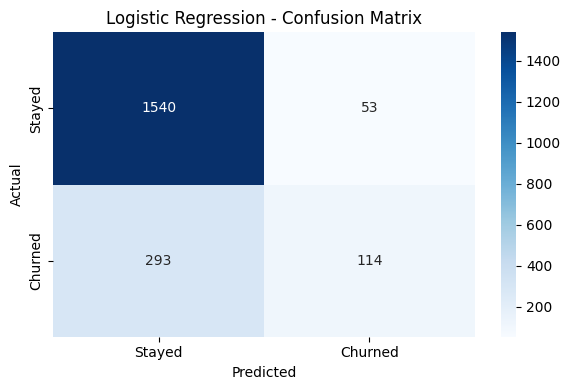

ROC-AUC Score: 0.7957973381702196


In [6]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC-AUC Score
lr_proba = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, lr_proba))

### Logistic Regression Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | 83% |
| F1 - Stayed | 0.90 |
| F1 - Churned | 0.40 |
| ROC-AUC | 0.796 |

**Observation:** The model performs well for majority class (Stayed) but 
struggles to identify churned customers, missing 293 out of 407 actual churners.
This is expected for a linear model with imbalanced data.

### Logistic Regression - K-Fold Cross Validation
We use 5-Fold CV to verify model performance is consistent across different data splits.

In [7]:
# Apply 5-Fold Cross Validation on Logistic Regression
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='f1')

print("Logistic Regression - 5-Fold Cross Validation F1 Scores:")
print(lr_cv_scores)
print("Mean F1 Score:", lr_cv_scores.mean().round(3))
print("Standard Deviation:", lr_cv_scores.std().round(3))

Logistic Regression - 5-Fold Cross Validation F1 Scores:
[0.35420394 0.39316239 0.40689655 0.44262295 0.38991597]
Mean F1 Score: 0.397
Standard Deviation: 0.029


## 6. Model 2: Decision Tree

#### Rationale

Decision Tree is selected as the second supervised learning model because:

- It can capture non-linear relationships between features and the target variable.
- It does not require feature scaling, making it robust to different feature magnitudes.
- It is highly interpretable, allowing us to visualize how decisions are made.
- It can automatically identify important features affecting customer churn.

#### Limitations

- Decision Trees can easily overfit the training data if not properly tuned.
- Small changes in data can lead to different tree structures.

### Decision Tree Training

In [36]:
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=31)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test data
dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")
print("Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree trained successfully!
Accuracy: 0.7905


### Decision Tree Evaluation

We evaluate the model using multiple metrics to understand its ability to correctly detect churned customers.

In [37]:
print("Classification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.86      0.87      1593
 Churned (1)       0.49      0.52      0.50       407

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.80      0.79      0.79      2000



### Confusion Matrix

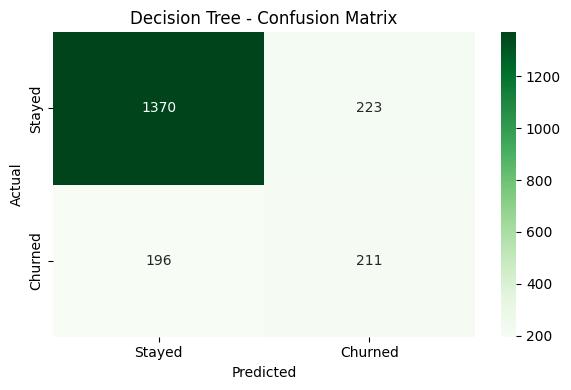

In [38]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### ROC-AUC Score

In [39]:
dt_proba = dt_model.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, dt_proba))

ROC-AUC Score: 0.6892200366776637


### Decision Tree Results Summary

| Metric | Value |
|------|------|
| Accuracy | 79.05% |
| F1 - Stayed | 0.86 |
| F1 - Churned | 0.49 |
| ROC-AUC | 0.680 |

**Observation:** Decision Tree can capture complex patterns in customer behavior, which may improve churn detection compared to linear models like Logistic Regression.


### Cross Validation for Decision Tree

In [40]:
dt_cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='f1')

print("Decision Tree - 5-Fold Cross Validation F1 Scores:")
print(dt_cv_scores)
print("Mean F1 Score:", dt_cv_scores.mean().round(3))
print("Standard Deviation:", dt_cv_scores.std().round(3))

Decision Tree - 5-Fold Cross Validation F1 Scores:
[0.46642247 0.52408931 0.47349823 0.50904704 0.48557692]
Mean F1 Score: 0.492
Standard Deviation: 0.022


### Feature Importance.  
#######زايد بشوف اذا احذفه او لا بس انه يحلل المودل مو النتايج

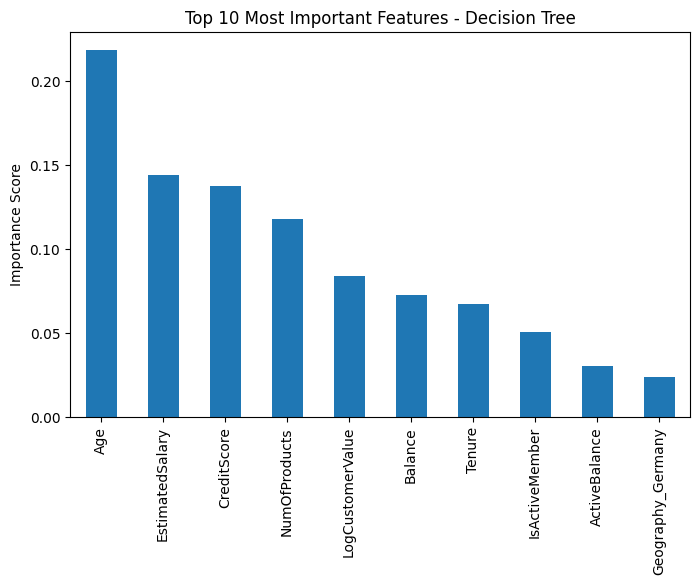

In [41]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Most Important Features - Decision Tree")
plt.ylabel("Importance Score")
plt.show()

The feature importance plot shows which variables have the strongest influence on predicting customer churn. Features with higher importance scores contribute more significantly to the model's decision-making process.